In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import json
import subprocess
from pathlib import Path
from dotenv import load_dotenv
from PIL import Image

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
sys.path.insert(0, str(Path(os.environ.get("PROJECT_ROOT", "."))))

In [ ]:
input_path = os.path.join(PROJECT_ROOT,"data/raw/original_manuscript/reproduction14453_100/8 - f. 003v - 004.jpg")
img = Image.open(input_path).convert("RGB")
kraken_output = os.path.join(PROJECT_ROOT,"data/processed/segmented_images/08_f_003v_004.json")
with open(kraken_output, "r", encoding="utf-8") as f:
            kraken_output = json.load(f)

In [ ]:
orig_crops = []
for id, line in enumerate(kraken_output.get("lines", [])):
    if "boundary" not in line:
        continue
    xs, ys = zip(*line["boundary"])
    left, upper = int(min(xs)), int(min(ys))
    right, lower = int(max(xs)), int(max(ys))
    crop_img = img.crop((left, upper, right, lower))
    orig_crops.append((f"Line_{id}", crop_img))


In [ ]:
orig_crops

[('Line_0', <PIL.Image.Image image mode=RGB size=18x80>),
 ('Line_1', <PIL.Image.Image image mode=RGB size=104x60>),
 ('Line_2', <PIL.Image.Image image mode=RGB size=63x70>),
 ('Line_3', <PIL.Image.Image image mode=RGB size=465x36>),
 ('Line_4', <PIL.Image.Image image mode=RGB size=421x31>),
 ('Line_5', <PIL.Image.Image image mode=RGB size=413x36>),
 ('Line_6', <PIL.Image.Image image mode=RGB size=408x33>),
 ('Line_7', <PIL.Image.Image image mode=RGB size=37x49>),
 ('Line_8', <PIL.Image.Image image mode=RGB size=419x42>),
 ('Line_9', <PIL.Image.Image image mode=RGB size=418x41>),
 ('Line_10', <PIL.Image.Image image mode=RGB size=318x34>),
 ('Line_11', <PIL.Image.Image image mode=RGB size=310x36>),
 ('Line_12', <PIL.Image.Image image mode=RGB size=882x44>),
 ('Line_13', <PIL.Image.Image image mode=RGB size=889x41>),
 ('Line_14', <PIL.Image.Image image mode=RGB size=413x36>),
 ('Line_15', <PIL.Image.Image image mode=RGB size=408x38>),
 ('Line_16', <PIL.Image.Image image mode=RGB size=401

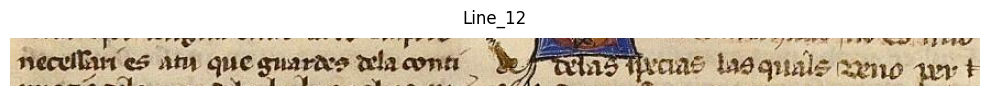

In [ ]:
line_id, cropped_img = orig_crops[12]

# Display it
plt.figure(figsize=(10, 2))  # Adjust size as needed
plt.imshow(cropped_img)
plt.axis('off')  # Hide axes
plt.title(line_id, pad=10)
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
img = Image.open(input_path)
print(img.size, img.mode)

(882, 44) RGB


In [2]:
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path(os.environ.get("PROJECT_ROOT", "."))))

from src.utils.path_utils import format_filename
from src.data_preprocessing.crop_image_segments import crop_image_segments

output_path, output_filename, processed_name = format_filename(base_name ="8 - f. 003v - 004" , output_folder="output_folder") 
print(f'output_path: {output_path} output_filename: {output_filename} processed_name: {processed_name}')

output_path: output_folder\08_f_003v_004.json output_filename: 08_f_003v_004.json processed_name: 08_f_003v_004


In [3]:
input_path = os.path.join(PROJECT_ROOT,"data/raw/original_manuscript/reproduction14453_100/8 - f. 003v - 004.jpg")
kraken_output = os.path.join(PROJECT_ROOT,"data/processed/segmented_images/08_f_003v_004.json")
project_root = Path(os.environ["PROJECT_ROOT"])
output_folder = project_root / "data" / "processed" / "extracted_lines"

In [5]:
crop_image_segments( img_path = input_path, kraken_output_path= kraken_output, processed_name = processed_name, output_path = output_folder)

True

## Cropping the image with the original polygon shape

In [12]:
import cv2
import numpy as np

def extract_polygon(image_path, polygon):
    img = cv2.imread(image_path)

    pts = np.array(polygon, dtype=np.int32)

    # Step 1: mask
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 255)

    # Step 2: apply mask
    masked = cv2.bitwise_and(img, img, mask=mask)

    # Step 3: crop tightly
    x, y, w, h = cv2.boundingRect(pts)
    cropped = masked[y:y+h, x:x+w]

    # 🔥 convert BGR → RGB BEFORE returning
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    return cropped_rgb

In [13]:
input_path = os.path.join(PROJECT_ROOT,"data/raw/original_manuscript/reproduction14453_100/37 - f. 032v - 033.jpg")
img = Image.open(input_path)#.convert("RGB")
kraken_output_path = os.path.join(PROJECT_ROOT,"data/processed/segmented_images/segmentation_20260430_123217/37_f_032v_033.json")
with open(kraken_output_path, "r", encoding="utf-8") as f:
            kraken_output = json.load(f)

In [14]:
orig_crops = []
for idx, line in enumerate(kraken_output.get("lines", [])):
    if "boundary" not in line:
        continue
    polygon = [(int(x), int(y)) for x, y in line["boundary"]]
    crop_img = extract_polygon(input_path, polygon)
    orig_crops.append((f"Line_{idx}", crop_img))

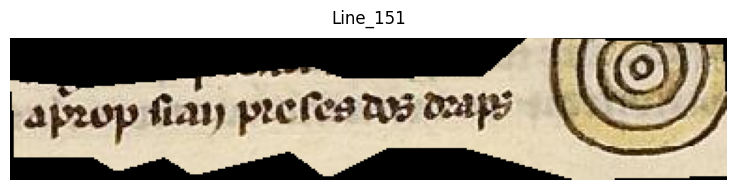

In [15]:
line_id, cropped_img = orig_crops[151]

# Display it
plt.figure(figsize=(10, 2))  # Adjust size as needed
plt.imshow(cropped_img)
plt.axis('off')  # Hide axes
plt.title(line_id, pad=10)
plt.tight_layout()
plt.show()